# Hybrid Search Evaluation: BM25 + Dense Retrieval

**Hybrid Search**, combining the existing dense (cosine-similarity) retriever with a **BM25** sparse/lexical retriever.

**Why Hybrid Search ?** :- the evaluation queries are the corpus questions themselves (verbatim). That means for every query, there exists a document with near-total *lexical* overlap — exactly the case BM25 is built to nail, and exactly the kind of exact/near-exact match a dense embedding model can sometimes rank lower than a semantically-similar-but-wrong neighbor. If Hit@1 is being lost to that failure mode, BM25 should recover it directly, with no retraining and near-zero added latency (BM25 is just term-frequency math, not a neural forward pass).

This notebook reuses the same setup, golden set, retrieval function, and metric functions as the `retriever_evaluation_dense.ipynb` notebook (same names throughout), then:

1. Builds a BM25 index over the same corpus.
2. Evaluates BM25 alone.
3. Combines dense + BM25 via Reciprocal Rank Fusion (RRF).
4. Evaluates the hybrid retriever.
5. Compares all three (dense / BM25 / hybrid) side by side quality, latency, and which specific queries changed.


In [1]:
import os
import re
import json
import time
import random
from pathlib import Path
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chromadb
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


d:\RAG_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Reconnect to the Existing Vector Store

In [ ]:
EMBEDDING_MODEL_NAME = "BAAI/bge-small-en-v1.5"
PERSIST_DIRECTORY = "../data/vector_store"
COLLECTION_NAME = "json_qa_documents"

print(f"Loading embedding model: {EMBEDDING_MODEL_NAME} ...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Model loaded.")

client = chromadb.PersistentClient(path=PERSIST_DIRECTORY)
collection = client.get_collection(name=COLLECTION_NAME)

print(f"Connected to collection '{COLLECTION_NAME}'")
print(f"Documents in collection: {collection.count()}")


Loading embedding model: BAAI/bge-small-en-v1.5 ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1364.13it/s]


Model loaded.
Connected to collection 'json_qa_documents'
Documents in collection: 2964


### 2. Golden Evaluation Set

In [ ]:
CORPUS_PATH = Path("../data/json_files/bliss_corpus.json")

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    corpus_records = json.load(f)

print(f"Loaded {len(corpus_records)} records from corpus")

eval_set = []
for record in corpus_records:
    doc_id = record.get("doc_id")
    question = record.get("question")
    if doc_id and question:
        meta = record.get("metadata", {})
        eval_set.append({
            "query": question,
            "relevant_doc_ids": [doc_id],
            "topic_group": meta.get("topic_group", "unknown"),
            "flags": meta.get("flags", []) or [],
        })


print(f"Built {len(eval_set)} query/ground-truth pairs")

SAMPLE_SIZE = 300
if SAMPLE_SIZE and SAMPLE_SIZE < len(eval_set):
    eval_set = random.sample(eval_set, SAMPLE_SIZE)
    print(f"Sampled down to {len(eval_set)} queries for this run")

for i, item in enumerate(eval_set):
    item["query_id"] = i

pd.DataFrame(eval_set).head()


Loaded 2964 records from corpus
Built 2964 query/ground-truth pairs
Sampled down to 300 queries for this run


,query,relevant_doc_ids,topic_group,flags,query_id
0,How does a counselor decide when to end counse...,[cc_q895_a013],treatment_and_help,[],0
1,I have so many issues to address. I have a his...,[cc_q0_a023],depression_mood,[long_personal_post_question],1
2,How do PANS/PANDAS symptoms differ from typica...,[nimh_pandas_03],neurodevelopmental,[],2
3,I feel too scared to meet people I don't know ...,[cc_q206_a001],anxiety_stress,[],3
4,When I'm in large crowds I get angry and I jus...,[cc_q159_a017],anxiety_stress,[long_personal_post_question],4


### 3. Dense Retrieval Function

In [4]:
def retrieve_for_eval(query: str, top_k: int) -> List[str]:
    """
    Retrieve the top_k document ids for a query, ranked best-first,
    with no similarity-score filtering.
    """
    query_embedding = embedding_model.encode([query])[0]
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k,
    )
    if results["ids"] and results["ids"][0]:
        return results["ids"][0]
    return []


### 4. Retrieval Metrics

Unchanged same 5 functions reused for every retriever evaluated in this notebook (dense, BM25, hybrid), so all numbers are directly comparable.

In [5]:
def hit_rate_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> int:
    top_k = retrieved_ids[:k]
    return int(any(doc_id in relevant_ids for doc_id in top_k))


def reciprocal_rank(retrieved_ids: List[str], relevant_ids: List[str]) -> float:
    for rank, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in relevant_ids:
            return 1.0 / rank
    return 0.0


def precision_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    top_k = retrieved_ids[:k]
    if not top_k:
        return 0.0
    num_relevant_in_top_k = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return num_relevant_in_top_k / len(top_k)


def recall_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    if not relevant_ids:
        return 0.0
    top_k = retrieved_ids[:k]
    num_relevant_found = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return num_relevant_found / len(relevant_ids)


def ndcg_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    top_k = retrieved_ids[:k]
    dcg = 0.0
    for i, doc_id in enumerate(top_k):
        relevance = 1.0 if doc_id in relevant_ids else 0.0
        dcg += relevance / np.log2(i + 2)
    num_relevant = min(len(relevant_ids), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(num_relevant))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate(retrieve_fn, eval_set, K_VALUES):
    """Run retrieve_fn(query, top_k=MAX_K) over eval_set and return a per-query results DataFrame."""
    max_k = max(K_VALUES)
    rows = []
    for item in eval_set:
        query = item["query"]
        relevant_ids = item["relevant_doc_ids"]
        retrieved_ids = retrieve_fn(query, max_k)

        row = {
            "query_id": item["query_id"],
            "query": query,
            "relevant_doc_ids": relevant_ids,
            "retrieved_doc_ids": retrieved_ids,
            "topic_group": item.get("topic_group", "unknown"),
            "flags": item.get("flags", []),
            "is_safety_sensitive": "safety_sensitive" in item.get("flags", []),
            "reciprocal_rank": reciprocal_rank(retrieved_ids, relevant_ids),
        }
        for k in K_VALUES:
            row[f"hit_rate@{k}"] = hit_rate_at_k(retrieved_ids, relevant_ids, k)
            row[f"precision@{k}"] = precision_at_k(retrieved_ids, relevant_ids, k)
            row[f"recall@{k}"] = recall_at_k(retrieved_ids, relevant_ids, k)
            row[f"ndcg@{k}"] = ndcg_at_k(retrieved_ids, relevant_ids, k)
        rows.append(row)
    return pd.DataFrame(rows)


def summarize(results_df, metric_cols):
    summary = results_df[metric_cols].mean().rename("score").to_frame()
    summary.loc["MRR"] = results_df["reciprocal_rank"].mean()
    return summary.round(4)


### 5. (Dense) Evaluation Run

In [6]:
K_VALUES = [1, 3, 5, 10]
MAX_K = max(K_VALUES)

results_df = evaluate(retrieve_for_eval, eval_set, K_VALUES)
metric_cols = [c for c in results_df.columns if "@" in c]
summary = summarize(results_df, metric_cols)

print(f"Dense baseline: evaluated {len(results_df)} queries")
summary


Dense baseline: evaluated 300 queries


,score
hit_rate@1,0.4433
precision@1,0.4433
recall@1,0.4433
ndcg@1,0.4433
hit_rate@3,0.6400
precision@3,0.2133
recall@3,0.6400
ndcg@3,0.5565
hit_rate@5,0.7167
precision@5,0.1433


## 6. Building the BM25 Index

BM25 is a sparse, lexical ranking function — it scores documents by term-frequency / inverse-document-frequency statistics over the actual words used, with no notion of semantic meaning. That's exactly what it's good at: exact terms, named entities, and specific phrasing that a dense embedding can blur together with semantically related-but-wrong neighbors. It's also essentially free at query time (no model forward pass), so combining it with the dense retriever costs almost nothing in latency — a sharp contrast to the reranker's ~1.9s hit.

We build the BM25 index over the same document text already stored in the vector store, fetched directly from ChromaDB so there's no risk of it drifting from what the dense retriever indexed.

In [7]:
all_docs = collection.get(include=["documents"])
corpus_ids = all_docs["ids"]
corpus_texts = all_docs["documents"]

print(f"Fetched {len(corpus_ids)} documents from the collection for the BM25 index")

def tokenize(text: str) -> List[str]:
    """Simple, dependency-free tokenizer: lowercase, strip punctuation, split on whitespace."""
    return re.findall(r"[a-z0-9]+", text.lower())

tokenized_corpus = [tokenize(doc) for doc in corpus_texts]
bm25_index = BM25Okapi(tokenized_corpus)

print("BM25 index built.")


Fetched 2964 documents from the collection for the BM25 index
BM25 index built.


In [8]:
def retrieve_bm25(query: str, top_k: int) -> List[str]:
    """Retrieve the top_k document ids for a query, ranked best-first, using BM25 alone."""
    scores = bm25_index.get_scores(tokenize(query))
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [corpus_ids[i] for i in top_indices]


# Quick sanity check
sample_query = eval_set[0]["query"]
print(f"Query: {sample_query}")
print(f"Expected relevant doc_id(s): {eval_set[0]['relevant_doc_ids']}")
print(f"Dense top 5: {retrieve_for_eval(sample_query, top_k=5)}")
print(f"BM25 top 5:  {retrieve_bm25(sample_query, top_k=5)}")


Query: How does a counselor decide when to end counseling sessions or to terminate working with a client?
Expected relevant doc_id(s): ['cc_q895_a013']
Dense top 5: ['cc_q895_a016', 'cc_q895_a012', 'cc_q895_a013', 'cc_q895_a004', 'cc_q895_a006']
BM25 top 5:  ['cc_q895_a012', 'cc_q895_a004', 'cc_q895_a015', 'cc_q895_a007', 'cc_q895_a016']


## 7. Standalone BM25 Evaluation Run

Worth measuring on its own, not just as part of the hybrid combination — this tells you whether BM25 alone is already competitive with the dense retriever on this corpus.

In [9]:
results_df_bm25 = evaluate(retrieve_bm25, eval_set, K_VALUES)
summary_bm25 = summarize(results_df_bm25, metric_cols)

print(f"BM25 alone: evaluated {len(results_df_bm25)} queries")
summary_bm25


BM25 alone: evaluated 300 queries


,score
hit_rate@1,0.4267
precision@1,0.4267
recall@1,0.4267
ndcg@1,0.4267
hit_rate@3,0.6333
precision@3,0.2111
recall@3,0.6333
ndcg@3,0.5475
hit_rate@5,0.7133
precision@5,0.1427


## 8. Combining Dense + BM25 with Reciprocal Rank Fusion (RRF)

Dense similarity scores (cosine, roughly -1 to 1) and BM25 scores (unbounded, corpus-dependent) aren't on comparable scales, so naively averaging them requires careful normalization and tuning. **Reciprocal Rank Fusion (RRF)** sidesteps that entirely: it only looks at each document's *rank position* in each retriever's results, not the raw scores.

For each candidate document, its RRF score is:

```
RRF_score(doc) = sum over each retriever r that returned doc of:  1 / (rrf_k + rank_r(doc))
```

where `rank_r(doc)` is that document's 1-indexed rank in retriever `r`'s results, and `rrf_k` is a small constant (60 is the standard default from the original RRF paper) that dampens the influence of very top ranks so one retriever can't dominate purely by ranking something #1. Documents found by *both* retrievers naturally rise to the top; documents found by only one still get a chance, weighted by how highly that one retriever ranked them. This needs no score normalization and no tuning to get a reasonable result — the standard reason RRF is the default fusion method in most production hybrid search systems (Elasticsearch, Weaviate, etc.).

In [23]:
FUSION_POOL_SIZE = 20   # candidates pulled from EACH retriever before fusion
RRF_K = 10               # standard RRF damping constant

def retrieve_hybrid(query: str, top_k: int, pool_size: int = FUSION_POOL_SIZE, rrf_k: int = RRF_K) -> List[str]:
    """Fuse dense and BM25 rankings with Reciprocal Rank Fusion, return top_k doc ids best-first."""
    dense_ranked = retrieve_for_eval(query, pool_size)
    bm25_ranked = retrieve_bm25(query, pool_size)

    rrf_scores: Dict[str, float] = {}
    for ranked_list in (dense_ranked, bm25_ranked):
        for rank, doc_id in enumerate(ranked_list, start=1):
            rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank)

    fused = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in fused[:top_k]]


# Quick sanity check
print(f"Query: {sample_query}")
print(f"Expected relevant doc_id(s): {eval_set[0]['relevant_doc_ids']}")
print(f"Hybrid top 5: {retrieve_hybrid(sample_query, top_k=5)}")


Query: How does a counselor decide when to end counseling sessions or to terminate working with a client?
Expected relevant doc_id(s): ['cc_q895_a013']
Hybrid top 5: ['cc_q895_a012', 'cc_q895_a016', 'cc_q895_a004', 'cc_q895_a013', 'cc_q895_a015']


## 9. Running the Hybrid Evaluation

In [24]:
results_df_hybrid = evaluate(lambda q, k: retrieve_hybrid(q, k), eval_set, K_VALUES)
summary_hybrid = summarize(results_df_hybrid, metric_cols)

print(f"Hybrid (dense + BM25, RRF): evaluated {len(results_df_hybrid)} queries")
summary_hybrid


Hybrid (dense + BM25, RRF): evaluated 300 queries


,score
hit_rate@1,0.4567
precision@1,0.4567
recall@1,0.4567
ndcg@1,0.4567
hit_rate@3,0.6333
precision@3,0.2111
recall@3,0.6333
ndcg@3,0.5611
hit_rate@5,0.7000
precision@5,0.1400


| Metric | @1 | @3 | @5 | @10 |
|-------|-----|----|----|-----|
| Hit Rate | 0.4567 | 0.6333 | 0.7000 | 0.8400 |
| Precision| 0.4567 | 0.2111 | 0.1400 | 0.0840 |
| Recall   | 0.4567 | 0.6333 | 0.7000 | 0.8400 |
| NDCG     | 0.4567 | 0.5611 | 0.5887 | 0.6340 |

**MRR** : `0.5701`

## 10. Three-Way Comparison — Dense vs. BM25 vs. Hybrid

In [19]:
comparison = pd.concat(
    [summary.rename(columns={"score": "dense"}),
     summary_bm25.rename(columns={"score": "bm25"}),
     summary_hybrid.rename(columns={"score": "hybrid"})],
    axis=1,
)
comparison["hybrid_vs_dense_delta"] = (comparison["hybrid"] - comparison["dense"]).round(4)
comparison


,dense,bm25,hybrid,hybrid_vs_dense_delta
hit_rate@1,0.4433,0.4267,0.4567,0.0134
precision@1,0.4433,0.4267,0.4567,0.0134
recall@1,0.4433,0.4267,0.4567,0.0134
ndcg@1,0.4433,0.4267,0.4567,0.0134
hit_rate@3,0.6400,0.6333,0.6333,-0.0067
precision@3,0.2133,0.2111,0.2111,-0.0022
recall@3,0.6400,0.6333,0.6333,-0.0067
ndcg@3,0.5565,0.5475,0.5611,0.0046
hit_rate@5,0.7167,0.7133,0.6967,-0.0200
precision@5,0.1433,0.1427,0.1393,-0.0040


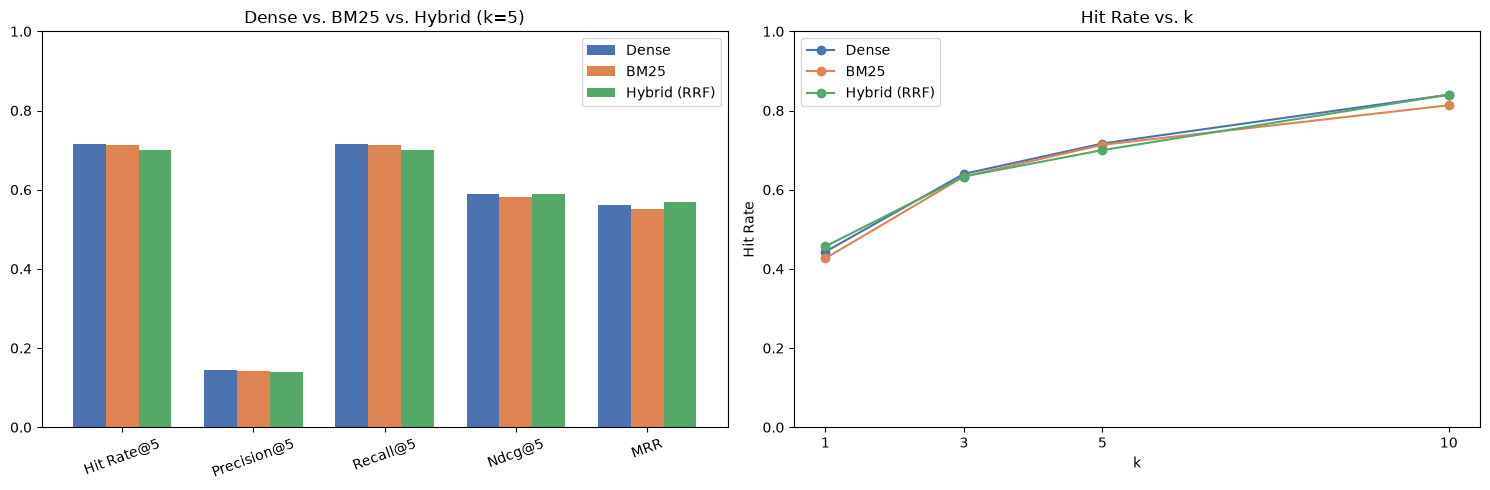

In [25]:
EVAL_K = 5
metrics_at_k = ["hit_rate", "precision", "recall", "ndcg"]

dense_vals = [results_df[f"{m}@{EVAL_K}"].mean() for m in metrics_at_k] + [results_df["reciprocal_rank"].mean()]
bm25_vals = [results_df_bm25[f"{m}@{EVAL_K}"].mean() for m in metrics_at_k] + [results_df_bm25["reciprocal_rank"].mean()]
hybrid_vals = [results_df_hybrid[f"{m}@{EVAL_K}"].mean() for m in metrics_at_k] + [results_df_hybrid["reciprocal_rank"].mean()]
labels = [f"{m.replace('_', ' ').title()}@{EVAL_K}" for m in metrics_at_k] + ["MRR"]

x = np.arange(len(labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(x - width, dense_vals, width, label="Dense", color="#4C72B0")
axes[0].bar(x, bm25_vals, width, label="BM25", color="#DD8452")
axes[0].bar(x + width, hybrid_vals, width, label="Hybrid (RRF)", color="#55A868")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_ylim(0, 1)
axes[0].set_title(f"Dense vs. BM25 vs. Hybrid (k={EVAL_K})")
axes[0].legend()

dense_hr = [results_df[f"hit_rate@{k}"].mean() for k in K_VALUES]
bm25_hr = [results_df_bm25[f"hit_rate@{k}"].mean() for k in K_VALUES]
hybrid_hr = [results_df_hybrid[f"hit_rate@{k}"].mean() for k in K_VALUES]
axes[1].plot(K_VALUES, dense_hr, marker="o", label="Dense", color="#4C72B0")
axes[1].plot(K_VALUES, bm25_hr, marker="o", label="BM25", color="#DD8452")
axes[1].plot(K_VALUES, hybrid_hr, marker="o", label="Hybrid (RRF)", color="#55A868")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Hit Rate")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(K_VALUES)
axes[1].set_title("Hit Rate vs. k")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Latency

BM25 and RRF fusion are both cheap (no neural inference), so the expectation is that hybrid stays close to the dense baseline's latency — unlike the reranker.

In [26]:
def time_calls(fn, items):
    latencies = []
    for item in items:
        start = time.perf_counter()
        fn(item["query"])
        latencies.append((time.perf_counter() - start) * 1000)
    return np.array(latencies)


latencies_ms_dense = time_calls(lambda q: retrieve_for_eval(q, top_k=MAX_K), eval_set)
latencies_ms_bm25 = time_calls(lambda q: retrieve_bm25(q, top_k=MAX_K), eval_set)
latencies_ms_hybrid = time_calls(lambda q: retrieve_hybrid(q, top_k=MAX_K), eval_set)

latency_comparison = pd.DataFrame({
    "dense_ms": [latencies_ms_dense.mean(), np.median(latencies_ms_dense), np.percentile(latencies_ms_dense, 95)],
    "bm25_ms": [latencies_ms_bm25.mean(), np.median(latencies_ms_bm25), np.percentile(latencies_ms_bm25, 95)],
    "hybrid_ms": [latencies_ms_hybrid.mean(), np.median(latencies_ms_hybrid), np.percentile(latencies_ms_hybrid, 95)],
}, index=["mean", "median", "p95"]).round(1)

latency_comparison["hybrid_added_ms"] = (latency_comparison["hybrid_ms"] - latency_comparison["dense_ms"]).round(1)
latency_comparison


,dense_ms,bm25_ms,hybrid_ms,hybrid_added_ms
mean,45.0,58.2,112.0,67.0
median,40.8,42.5,91.3,50.5
p95,65.7,133.5,215.0,149.3


## 12. Which Specific Queries Did Hybrid Fix?

Joined on `query_id` this time (not query text) so repeated questions in the corpus can't inflate the counts the way they may have in the reranker notebook.

In [27]:
merged = results_df[["query_id", "query", f"hit_rate@{EVAL_K}"]].merge(
    results_df_hybrid[["query_id", f"hit_rate@{EVAL_K}", "retrieved_doc_ids"]],
    on="query_id", suffixes=("_dense", "_hybrid")
)

fixed = merged[(merged[f"hit_rate@{EVAL_K}_dense"] == 0) & (merged[f"hit_rate@{EVAL_K}_hybrid"] == 1)]
broken = merged[(merged[f"hit_rate@{EVAL_K}_dense"] == 1) & (merged[f"hit_rate@{EVAL_K}_hybrid"] == 0)]

print(f"Fixed by hybrid (miss -> hit @ k={EVAL_K}):  {len(fixed)} queries")
print(f"Broken by hybrid (hit -> miss @ k={EVAL_K}): {len(broken)} queries")
print(f"Net change: {len(fixed) - len(broken):+d} queries  (should match the hit_rate@{EVAL_K} delta x {len(merged)} queries)")

fixed[["query"]].head(10)


Fixed by hybrid (miss -> hit @ k=5):  6 queries
Broken by hybrid (hit -> miss @ k=5): 11 queries
Net change: -5 queries  (should match the hit_rate@5 delta x 300 queries)


,query
93,How does a counselor decide when to end counse...
178,My daughter is in later elementary school. She...
215,I've gone to a couple therapy sessions so far ...
228,I have a fear of something and I want to face ...
241,I have a friend that who I used to be in a rel...
263,I have so many issues to address. I have a his...


## 13. Stratified Check — Safety-Sensitive Content

In [28]:
def stratify(df, label):
    out = df.groupby("is_safety_sensitive").agg(
        n_queries=("query", "count"),
        hit_rate=(f"hit_rate@{EVAL_K}", "mean"),
        mrr=("reciprocal_rank", "mean"),
        ndcg=(f"ndcg@{EVAL_K}", "mean"),
    ).round(4)
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out


strat_compare = pd.concat(
    [stratify(results_df, "dense"), stratify(results_df_bm25, "bm25"), stratify(results_df_hybrid, "hybrid")],
    axis=1,
)
strat_compare


dense                               bm25           \
                    n_queries hit_rate     mrr    ndcg n_queries hit_rate   
is_safety_sensitive                                                         
False                     293   0.7099  0.5523  0.5795       293   0.7099   
True                        7   1.0000  0.9286  0.9473         7   0.8571   

                                       hybrid                           
                        mrr    ndcg n_queries hit_rate     mrr    ndcg  
is_safety_sensitive                                                     
False                0.5457  0.5762       293   0.6928  0.5639  0.5818  
True                 0.7321  0.7517         7   1.0000  0.8333  0.8758

## 14. Summary & Next Steps

**What to check first:** the `hybrid_vs_dense_delta` column in Section 10, specifically at Hit Rate@1 — that's the exact metric the reranker failed to move. Also compare the standalone `bm25` column against `dense`: if BM25 alone already beats dense at Hit@1, that's strong confirmation of the lexical-overlap theory from the intro, and the interesting question becomes whether hybrid beats *either* alone or just matches the better of the two.

**If hybrid clearly wins:**
1. Wire `retrieve_hybrid` into the production `RAGRetriever` — fetch `FUSION_POOL_SIZE` candidates from each of the dense collection query and the BM25 index, fuse with RRF, then apply `score_threshold`-style filtering on the fused ranking (note: RRF scores aren't similarity scores, so the threshold semantics will need rethinking — likely just take the fused top-k directly rather than filtering by a similarity cutoff).
2. Persist the BM25 index alongside the vector store (`rank_bm25`'s `BM25Okapi` isn't natively persistent — pickle it, or rebuild at startup from the same corpus source used in Section 6) so production doesn't rebuild it per request.
3. Re-run with `SAMPLE_SIZE = None` for a full-corpus confirmation, and re-check Section 13 to confirm the safety-sensitive slice holds up.

**If hybrid doesn't clearly beat BM25 or dense alone:**
- Try tuning `RRF_K` (lower values weight top ranks more heavily) or `FUSION_POOL_SIZE`.
- Consider a weighted-sum fusion instead of RRF, with min-max normalized scores per retriever — more tuning required, but can outperform RRF once tuned.
- If BM25 alone is already strong, it may be simpler and cheaper to route queries by type (near-verbatim / keyword-heavy queries to BM25, paraphrased/conceptual queries to dense) rather than always fusing both.


In [29]:
broken

,query_id,query,hit_rate@5_dense,hit_rate@5_hybrid,retrieved_doc_ids
6,6,"I tried telling my husband I was depressed, an...",1,0,"[cc_q12_a001, cc_q12_a006, cc_q12_a009, cc_q12..."
28,28,I've gone to a couple therapy sessions so far ...,1,0,"[cc_q146_a022, cc_q146_a012, cc_q146_a018, cc_..."
31,31,"Sometimes, I'm fine and can go out or meet peo...",1,0,"[cc_q209_a006, cc_q209_a004, cc_q209_a007, cc_..."
71,71,My fiancé and I have been together for 3 years...,1,0,"[cc_q491_a005, cc_q491_a004, cc_q491_a006, cc_..."
98,98,My daughter is in later elementary school. She...,1,0,"[cc_q264_a009, cc_q264_a006, cc_q264_a008, cc_..."
133,133,I have so many issues to address. I have a his...,1,0,"[cc_q0_a053, cc_q0_a013, cc_q0_a032, cc_q0_a06..."
146,146,"I have anxieties about everyday stressors, i.e...",1,0,"[cc_q165_a004, cc_q165_a005, cc_q165_a006, cc_..."
207,207,I don't know what to say. I have never really ...,1,0,"[cc_q405_a008, cc_q405_a009, cc_q405_a001, cc_..."
225,225,Does counseling really do anything that can he...,1,0,"[cc_q935_a004, cc_q935_a005, cc_q935_a002, cc_..."
237,237,I start counseling/therapy in a few days (I'm ...,1,0,"[cc_q144_a006, cc_q144_a010, cc_q144_a001, cc_..."
